<p style="text-align:center;">
    <img src='../utils/digrams/eda_diagram_1.png' width="1000">
</p>

# NYC Trip_Duration


#### This EDA for New York City Taxi Trip Duration project inspired by kaggle project to calculate the total duration for taxi driving in New York


#### from kaggle 
#### ***id*** - a unique identifier for each trip

#### ***vendor_id*** - a code indicating the provider associated with the trip record

#### ***dropoff_datetime*** - date and time when the meter was disengaged

#### ***passenger_count*** - the number of passengers in the vehicle (driver entered value)

#### ***pickup_longitude*** - the longitude where the meter was engaged

#### ***pickup_latitude*** - the latitude where the meter was engaged

#### ***dropoff_longitude*** - the longitude where the meter was disengaged

#### ***dropoff_latitude*** - the latitude where the meter was disengaged

#### ***store_and_fwd_flag*** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip

#### ***trip_duration*** - duration of the trip in seconds



### Exploration


In [161]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv('../data/train.csv')
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1385950,1,2016-01-08 22:31:12,1,-73.990646,40.751068,-73.995789,40.728146,N,525
1,id1885523,2,2016-01-02 12:36:39,1,-73.982658,40.745071,-74.003258,40.732971,N,799
2,id0892204,2,2016-02-21 00:24:16,1,-73.999481,40.728580,-74.000252,40.718800,N,374
3,id2463973,2,2016-05-08 15:06:34,1,-73.977058,40.759850,-73.949989,40.776001,N,696
4,id1496105,2,2016-05-06 13:54:36,2,-73.977798,40.758221,-73.993080,40.743130,N,703


In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   str    
 1   vendor_id           5000 non-null   int64  
 2   pickup_datetime     5000 non-null   str    
 3   passenger_count     5000 non-null   int64  
 4   pickup_longitude    5000 non-null   float64
 5   pickup_latitude     5000 non-null   float64
 6   dropoff_longitude   5000 non-null   float64
 7   dropoff_latitude    5000 non-null   float64
 8   store_and_fwd_flag  5000 non-null   str    
 9   trip_duration       5000 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 532.4 KB


In [164]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.52000,1.65440,-73.973659,40.751530,-73.972305,40.752438,969.608200
std,0.49965,1.29325,0.057585,0.042378,0.056861,0.045901,3616.929016
min,1.00000,1.00000,-74.177292,40.619514,-74.183403,40.575306,2.000000
25%,1.00000,1.00000,-73.991638,40.737639,-73.991266,40.735735,392.000000
50%,2.00000,1.00000,-73.981895,40.754238,-73.979771,40.754862,656.000000
75%,2.00000,2.00000,-73.967855,40.768205,-73.962240,40.770319,1066.000000
max,2.00000,6.00000,-70.851616,43.017578,-70.851616,43.017578,86329.000000


### Check missing values

In [165]:

df.isna().sum().sum()

np.int64(0)

### Check Dublicates 


In [166]:

df.duplicated().sum()

np.int64(0)

### Check Outliers

In [167]:

numberic_features = df.select_dtypes(np.number).columns

for feature in numberic_features:
    first_quartile = df[feature].quantile(0.25)
    third_quartile = df[feature].quantile(0.75)
    interquartile_range = third_quartile - first_quartile 

    lower_bount = first_quartile - (1.5 * interquartile_range)
    upper_bount = third_quartile + (1.5 * interquartile_range)
    mask = df[(df[feature] < lower_bount) | (df[feature] > upper_bount)]
    if not mask.empty:
        print(f"{feature} has outlier {len(mask)}")


passenger_count has outlier 516
pickup_longitude has outlier 261
pickup_latitude has outlier 174
dropoff_longitude has outlier 249
dropoff_latitude has outlier 253
trip_duration has outlier 218


In [168]:
print(df.shape)

for feature in numberic_features:
    first_quartile = df[feature].quantile(0.25)
    third_quartile = df[feature].quantile(0.75)
    interquartile_range = third_quartile - first_quartile 

    lower_bount = first_quartile - (1.5 * interquartile_range)
    upper_bount = third_quartile + (1.5 * interquartile_range)
    df[feature] = np.clip(df[feature], lower_bount, upper_bount)


(5000, 10)


### EDA 

In [169]:

def info(col):
    print("min",df[col].min())
    print("max",df[col].max())
    print("Standard Deviation",df[col].std())
    print("Skewness",df[col].skew())
    Num_of_unique = df[col].nunique()
    print("Number of Unique Values",Num_of_unique)
    print(df[col].value_counts()) 



In [170]:
def group_by(col,fun):
    return df.groupby(col)["trip_duration"].agg(fun).reset_index() #Aggregate our function 

### Trip Duration Anaylsis


In [171]:
Target = df.iloc[:,-1]
Target

0       525
1       799
2       374
3       696
4       703
       ... 
4995    542
4996     74
4997    409
4998    763
4999    473
Name: trip_duration, Length: 5000, dtype: int64

In [172]:
info("trip_duration")

min 2
max 2077
Standard Deviation 516.9344577775092
Skewness 0.9577929403780233
Number of Unique Values 1592
trip_duration
2077    219
229      12
716      11
441      11
580      11
       ... 
949       1
1564      1
497       1
1647      1
1992      1
Name: count, Length: 1592, dtype: int64


In [173]:
df["log_trip_duration"] = np.log1p(Target)
info("log_trip_duration")

min 1.0986122886681098
max 7.639161171659173
Standard Deviation 0.7529057604240488
Skewness -0.9706687131188868
Number of Unique Values 1592
log_trip_duration
7.639161    219
5.438079     12
6.575076     11
6.091310     11
6.364751     11
           ... 
6.856462      1
7.355641      1
6.210600      1
7.407318      1
7.597396      1
Name: count, Length: 1592, dtype: int64


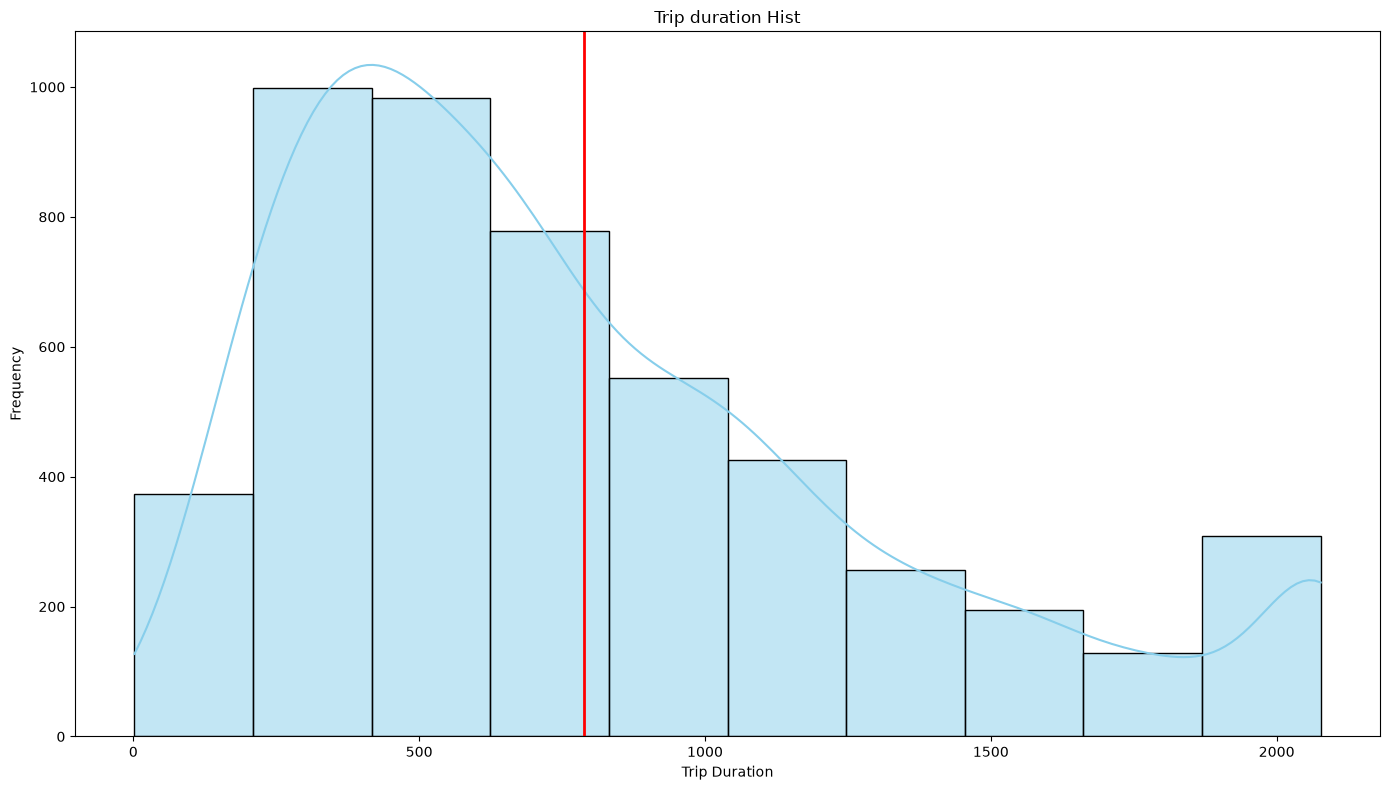

In [174]:
plt.figure(figsize=(14,8))

sns.histplot(Target, kde=True, bins=10, color="skyblue", edgecolor="black")
plt.axvline(Target.mean(), color="red", linewidth=2, label='Mean')


plt.title("Trip duration Hist")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Numerical Analysis

In [175]:
numberic_features

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration'],
      dtype='str')

In [176]:
info("vendor_id")

min 1
max 2
Standard Deviation 0.49964980735110587
Skewness -0.08008810533662761
Number of Unique Values 2
vendor_id
2    2600
1    2400
Name: count, dtype: int64


In [177]:
sum_vendor_id = group_by("vendor_id","count")
sum_vendor_id


,vendor_id,trip_duration
0,1,2400
1,2,2600


### passenger_count

In [178]:
info('passenger_count')

min 1.0
max 3.5
Standard Deviation 0.8486460039427521
Skewness 1.5089737456531491
Number of Unique Values 4
passenger_count
1.0    3542
2.0     734
3.5     516
3.0     208
Name: count, dtype: int64


In [179]:
total_passenger_count_during_trip = group_by("passenger_count","sum")
total_passenger_count_during_trip.sort_values(by="trip_duration", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds",subset=["trip_duration"])

,passenger_count,trip_duration
0,1.000000,2753522
1,2.000000,603169
2,3.500000,422915
3,3.000000,162379


D:\temp\ipykernel_5092\173218913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_vendor_id, x="vendor_id", y="trip_duration", palette="Reds", ax=axes[0])
D:\temp\ipykernel_5092\173218913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_passenger_count_during_trip, x="passenger_count", y="trip_duration", palette="Reds", ax=axes[1])


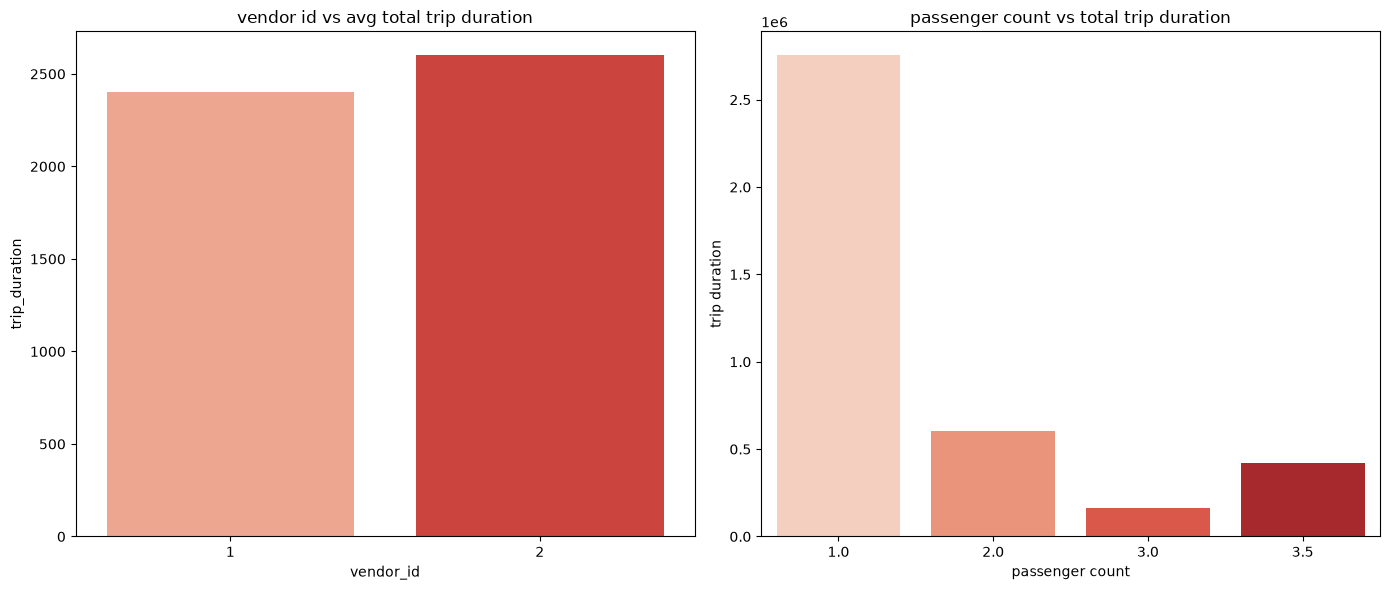

In [180]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.barplot(data=sum_vendor_id, x="vendor_id", y="trip_duration", palette="Reds", ax=axes[0])
axes[0].set_title("vendor id vs avg total trip duration")
axes[0].set_xlabel("vendor_id")
axes[0].set_ylabel("trip_duration")

sns.barplot(data=total_passenger_count_during_trip, x="passenger_count", y="trip_duration", palette="Reds", ax=axes[1])
axes[1].set_title("passenger count vs total trip duration")
axes[1].set_xlabel("passenger count")
axes[1].set_ylabel("trip duration")

plt.tight_layout()
plt.show()

In [181]:
df['passenger_count'].value_counts() 

passenger_count
1.0    3542
2.0     734
3.5     516
3.0     208
Name: count, dtype: int64

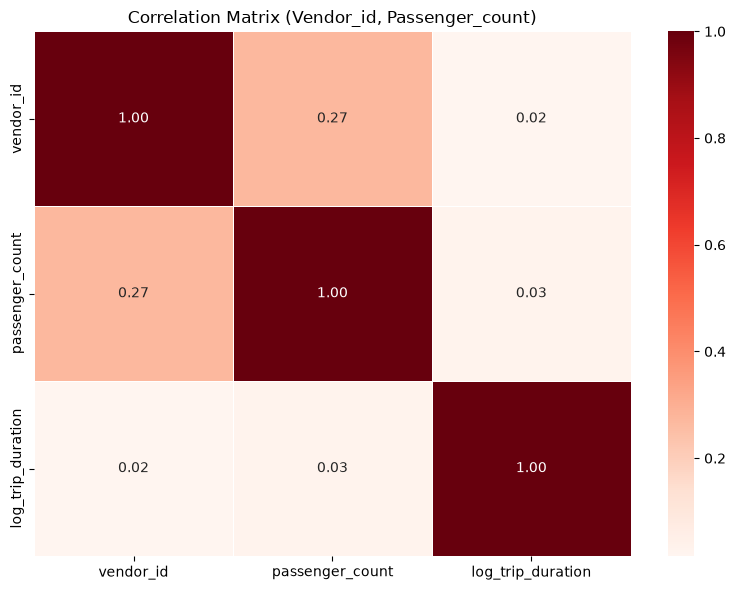

In [182]:
feats = df[["vendor_id","passenger_count","log_trip_duration"]]

corr_matrix = feats.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Reds", fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix (Vendor_id, Passenger_count)")
plt.tight_layout()
plt.show()


#### Longitude & Latitude analysis

In [183]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

In [184]:
for feature in features:
    print("-"*10,feature,"-"*10)
    info(feature)

---------- pickup_longitude ----------
min -74.02731227874756
max -73.9321813583374
Standard Deviation 0.019397829730842857
Skewness 0.5911425058955245
Number of Unique Values 3509
pickup_longitude
-73.932181    258
-73.982224      7
-73.982140      6
-73.983932      5
-73.976273      5
             ... 
-73.957069      1
-73.978348      1
-73.965240      1
-73.951324      1
-73.955864      1
Name: count, Length: 3509, dtype: int64
---------- pickup_latitude ----------
min 40.69179153442383
max 40.81405258178711
Standard Deviation 0.024328052811140102
Skewness -0.2899844252865009
Number of Unique Values 4214
pickup_latitude
40.691792    146
40.814053     28
40.774101      6
40.750221      5
40.761501      5
            ... 
40.740101      1
40.718163      1
40.770569      1
40.743710      1
40.784939      1
Name: count, Length: 4214, dtype: int64
---------- dropoff_longitude ----------
min -74.03480529785162
max -73.91870117187494
Standard Deviation 0.02267935607456904
Skewness 0.73024

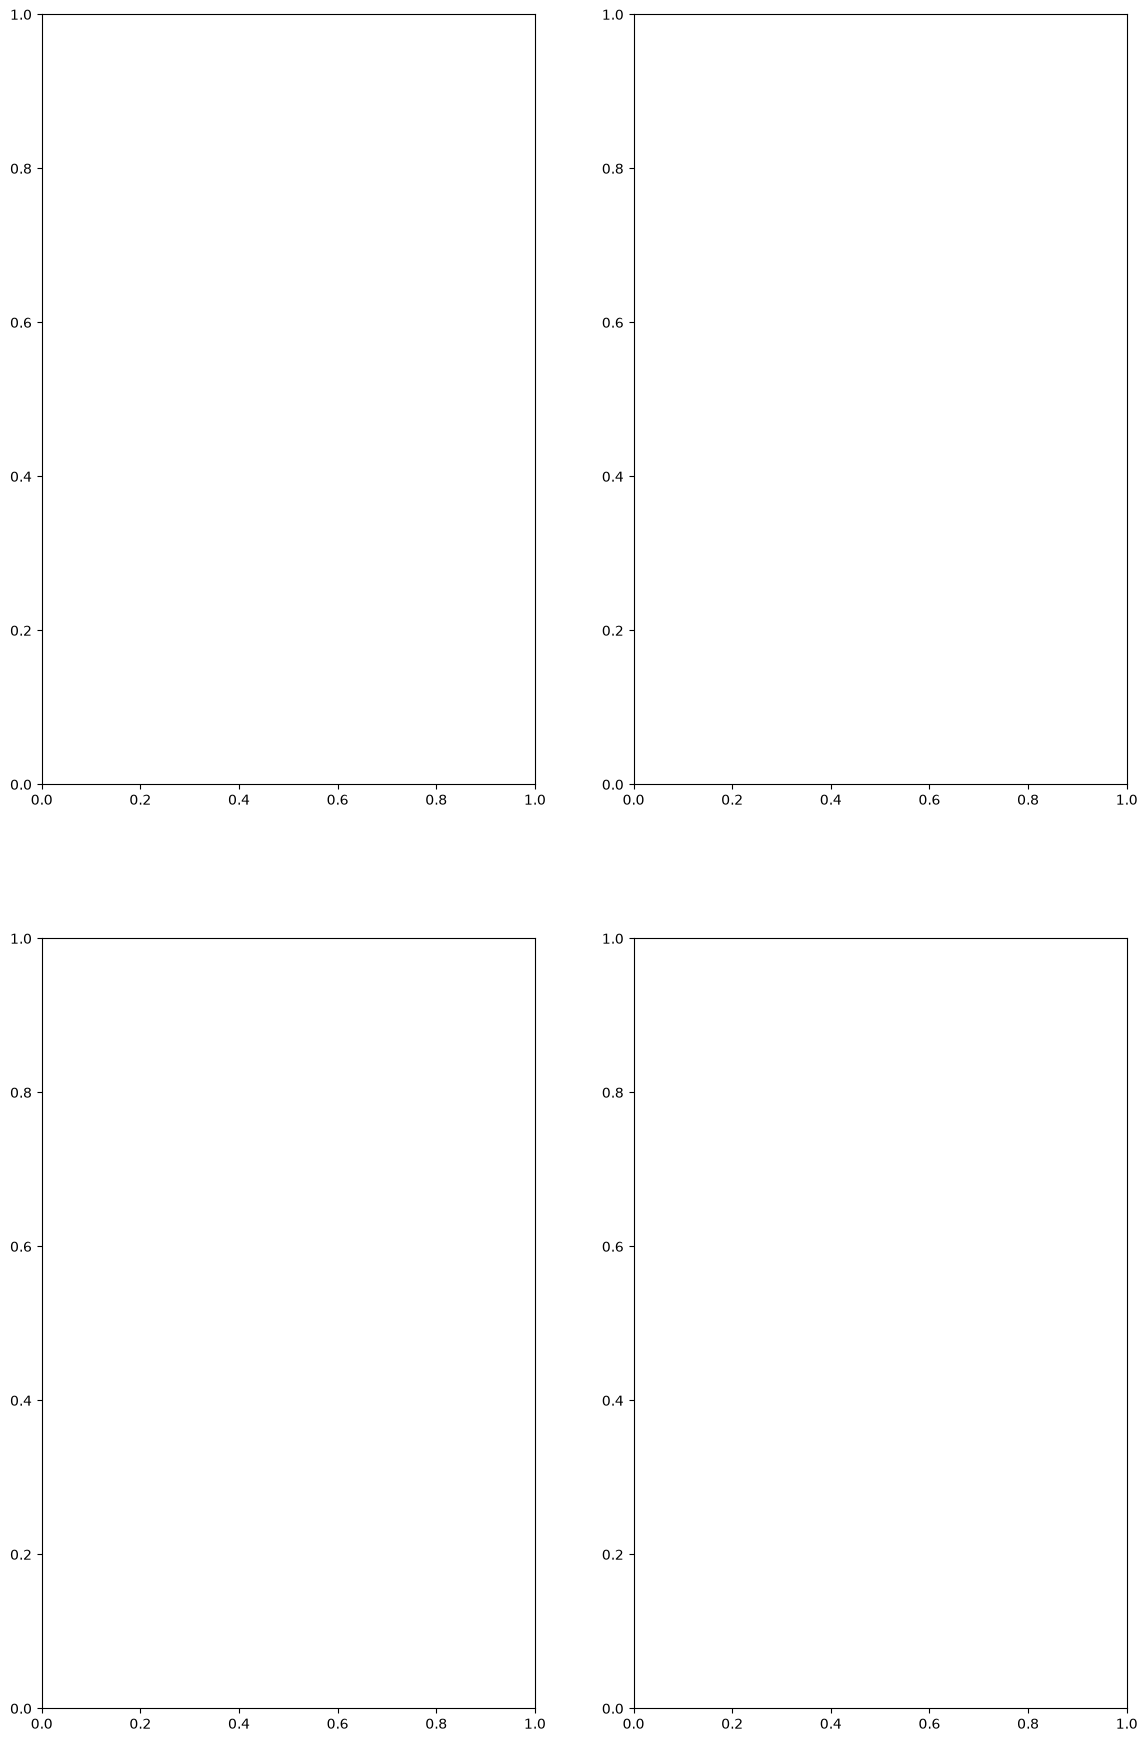

In [185]:
y = df['trip_duration']

plt.figure(figsize=(14,22))

for i in range(4):
    ax = plt.subplot(2,2,i+1)
    hb = ax.hexbin


In [186]:
def haversine(lat1,lon1,lat2,lon2):
    R = 6371  # Radius of the Earth in kilometers
    lat1,lon1,lat2,lon2 = map(np.radians,[lat1,lon1,lat2,lon2]) 
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance
df['haversine_distance'] = haversine(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
df['haversine_distance']

0       2.585424
1       2.195988
2       1.089522
3       2.902086
4       2.114919
          ...   
4995    1.691247
4996    0.157557
4997    2.256683
4998    1.895176
4999    1.921223
Name: haversine_distance, Length: 5000, dtype: float64

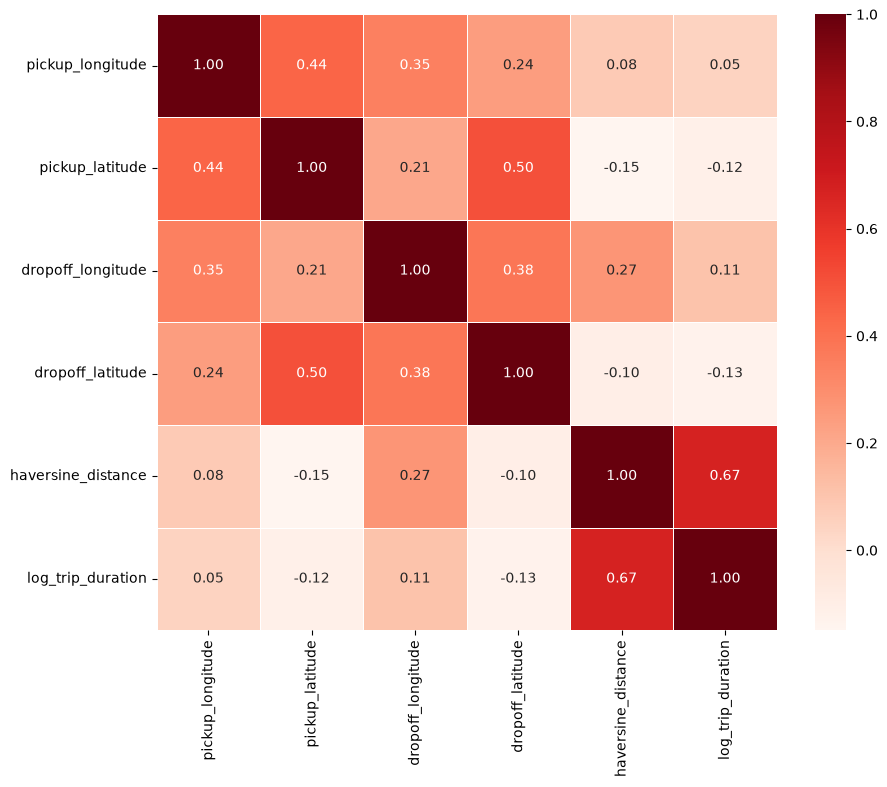

In [187]:
matrix = df[['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','haversine_distance','log_trip_duration']]
corr_matrix = matrix.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True, cmap="Reds", fmt=".2f",linewidths=0.5)
plt.show()

### Categorical Analysis

#### Store and fwd flag

In [188]:
from sklearn.preprocessing import LabelEncoder
feat = 'store_and_fwd_flag'
le = LabelEncoder()
df[feat] = le.fit_transform(df[feat]) 
df[feat].value_counts()

store_and_fwd_flag
0    4964
1      36
Name: count, dtype: int64

In [189]:
info('store_and_fwd_flag')

min 0
max 1
Standard Deviation 0.0845552477258721
Skewness 11.660948601980271
Number of Unique Values 2
store_and_fwd_flag
0    4964
1      36
Name: count, dtype: int64


In [190]:
store_fwd_group = group_by('store_and_fwd_flag','sum')
store_fwd_group

,store_and_fwd_flag,trip_duration
0,0,3911605
1,1,30380


#### Pickup datetime


In [191]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
print(df['pickup_datetime'].dtype)


datetime64[us]


In [192]:
df['year'] =df['pickup_datetime'].dt.year
df['month'] =df['pickup_datetime'].dt.month
df['day_of_week'] =df['pickup_datetime'].dt.day_of_week
df['hour'] =df['pickup_datetime'].dt.hour
df['day_name'] =df['pickup_datetime'].dt.day_name()
print(df[['year','month','day_of_week','hour','day_name']].head(10))

   year  month  day_of_week  hour   day_name
0  2016      1            4    22     Friday
1  2016      1            5    12   Saturday
2  2016      2            6     0     Sunday
3  2016      5            6    15     Sunday
4  2016      5            4    13     Friday
5  2016      4            0    18     Monday
6  2016      1            0    19     Monday
7  2016      2            2    22  Wednesday
8  2016      2            5    22   Saturday
9  2016      4            2    16  Wednesday


In [193]:
most_day_ride_duration = group_by('day_name','sum')
most_day_ride_duration.sort_values(by="trip_duration", ascending=False).head(2).reset_index(drop=True).style.background_gradient(cmap="Reds",subset=["trip_duration"])

,day_name,trip_duration
0,Friday,637950
1,Thursday,621460


In [194]:
most_hour_ride_duration = group_by('hour','sum')
most_hour_ride_duration.sort_values(by="trip_duration", ascending=False).head(2).reset_index(drop=True).style.background_gradient(cmap="Reds",subset=["trip_duration"])

,hour,trip_duration
0,13,239249
1,19,234949


In [195]:
def getseason(month):
    if   4<= month <=7:
        return "Spring"
    elif 8 <= month <= 10:
        return "Summer"
    elif  11<= month <=12:
        return "Fall"
    else:
        return "Winter"
    

df["season"] = df['pickup_datetime'].dt.month.apply(getseason)
df['season'].value_counts()

season
Winter    2545
Spring    2455
Name: count, dtype: int64

In [196]:
dt_df = df[['year', 'month', 'day_of_week', 'hour', 'season']]
dt_df.head()

,year,month,day_of_week,hour,season
0,2016,1,4,22,Winter
1,2016,1,5,12,Winter
2,2016,2,6,0,Winter
3,2016,5,6,15,Spring
4,2016,5,4,13,Spring


In [197]:
from sklearn.preprocessing import LabelEncoder

feat = 'season'

le = LabelEncoder()

df['season_encoder'] = le.fit_transform(df[feat])
df['season_encoder'].value_counts()

season_encoder
1    2545
0    2455
Name: count, dtype: int64

In [198]:
df.drop('season', axis=1, inplace=True)

In [199]:
df.drop('year', axis=1, inplace=True)

In [200]:
info('month')

min 1
max 6
Standard Deviation 1.6811039414897637
Skewness 0.021035102161972494
Number of Unique Values 6
month
3    901
2    863
5    833
4    822
6    800
1    781
Name: count, dtype: int64


In [201]:
month_sum_group = group_by('month', 'sum')
month_sum_group.sort_values(by="trip_duration", ascending=False).reset_index(drop=True).style.background_gradient(cmap="Reds", subset=['trip_duration'])

,month,trip_duration
0,3,698800
1,5,681320
2,6,668200
3,2,659197
4,4,643351
5,1,591117


In [202]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration',
       'log_trip_duration', 'haversine_distance', 'month', 'day_of_week',
       'hour', 'day_name', 'season_encoder'],
      dtype='str')

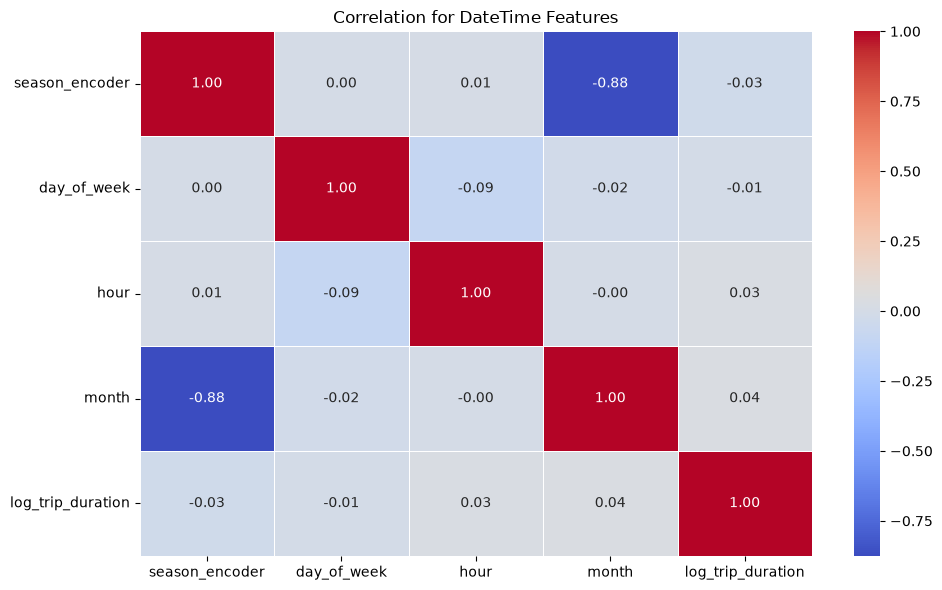

In [203]:
dt_df = df[['season_encoder', 'day_of_week', 'hour', 'month', 'log_trip_duration']]

corr_matrix = dt_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation for DateTime Features')
plt.tight_layout()
plt.show()

In [204]:
df.drop('id', axis=1, inplace=True )

In [205]:
df.drop('day_name', axis=1, inplace=True )

In [206]:
df.drop('log_trip_duration', axis=1, inplace=True )

In [207]:
df.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,haversine_distance,month,day_of_week,hour,season_encoder
0,1,2016-01-08 22:31:12,1.0,-73.990646,40.751068,-73.995789,40.728146,0,525,2.585424,1,4,22,1
1,2,2016-01-02 12:36:39,1.0,-73.982658,40.745071,-74.003258,40.732971,0,799,2.195988,1,5,12,1
2,2,2016-02-21 00:24:16,1.0,-73.999481,40.728580,-74.000252,40.718800,0,374,1.089522,2,6,0,1
3,2,2016-05-08 15:06:34,1.0,-73.977058,40.759850,-73.949989,40.776001,0,696,2.902086,5,6,15,0
4,2,2016-05-06 13:54:36,2.0,-73.977798,40.758221,-73.993080,40.743130,0,703,2.114919,5,4,13,0


In [208]:
corr_matrix = df.corr()

target_corr = corr_matrix.iloc[:,8].reset_index().sort_values(by='trip_duration', ascending=False)
print(target_corr.head(7), end='\n\n')
print(target_corr.tail(6))

                 index  trip_duration
8        trip_duration       1.000000
9   haversine_distance       0.746521
5    dropoff_longitude       0.163670
3     pickup_longitude       0.111521
10               month       0.052331
1      pickup_datetime       0.051393
2      passenger_count       0.028055

                 index  trip_duration
7   store_and_fwd_flag       0.009143
0            vendor_id       0.005119
11         day_of_week      -0.012665
13      season_encoder      -0.044394
4      pickup_latitude      -0.143787
6     dropoff_latitude      -0.167871


### Conclusion

- Original data contains **10 features**
- Drop `id` useless feature
- Data are clean: **no missing** & *no duplicate* from EDA

- Target (Trip Duration)
  - Before removing outliers, the data had **very high variance**.
  - After removing outliers, the distribution became almost **Gaussian**.

- Most passengers are **1** or **2**, with a few high outliers.

- We calculated **Haversine Distance** from longitude & latitude and obtained a strong correlation with the target.

- From datetime:
  - Thursday and Friday have the highest number of trips.
  - Most trips occur around **18:00** and **19:00**.
  - Datetime features have low correlation with the target.
  - Since all data were collected in **2016**, the year feature was removed.

- Top 5 correlated features:
  - `haversine_distance`
  - `dropoff_longitude`
  - `pickup_longitude`
  - `dropoff_latitude`
  - `pickup_latitude`